In [ ]:
# Part D: Customer Churn Prediction Mini-Project
### Mafeyisopin Ayeni | Machine Learning Assignment | 2025

This notebook is an end-to-end machine learning project predicting customer churn
using the Telco Customer Churn dataset from Kaggle (7,043 records, 21 features).

The notebook covers data cleaning, exploratory data analysis, feature engineering
(tenure_group and total_services), training and comparing GBM and XGBoost models,
handling class imbalance using scale_pos_weight, and interpreting results using SHAP
to identify the main drivers of churn.

In [ ]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape after cleaning: (7032, 21)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


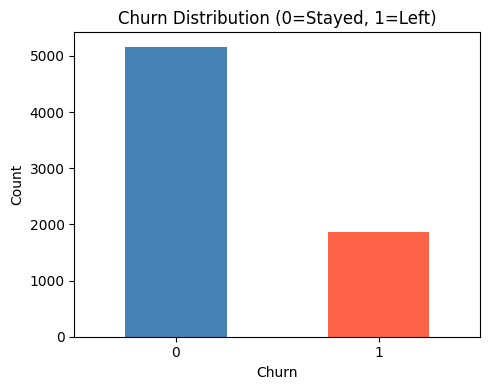

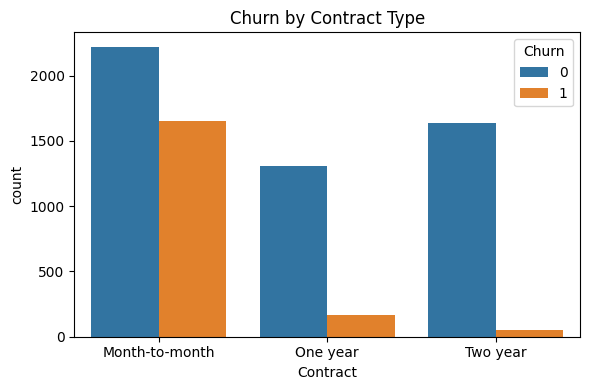

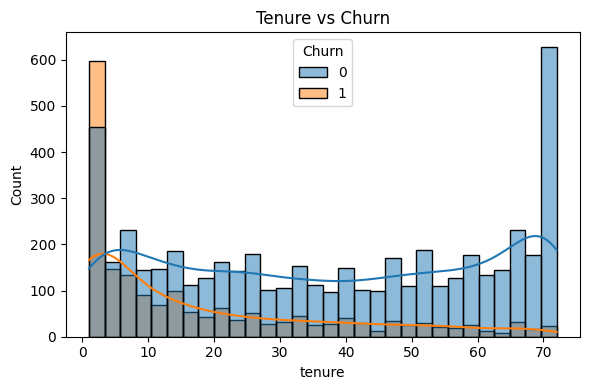

In [ ]:
# Cell 1 — Step 1: Data Cleaning + EDA plots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges column (it has spaces, should be numbers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Convert Churn to 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Shape after cleaning:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())

# Plot 1 - Churn distribution
plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn Distribution (0=Stayed, 1=Left)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2 - Churn by Contract type
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.tight_layout()
plt.show()

# Plot 3 - Tenure vs Churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure vs Churn')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 2 — Step 2: Feature Engineering

# New feature 1: tenure group
def tenure_group(t):
    if t <= 12: return 'New'
    elif t <= 24: return 'Growing'
    elif t <= 48: return 'Mature'
    else: return 'Loyal'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# New feature 2: total services count
services = ['PhoneService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df['total_services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

print("New features added:")
print(df[['tenure','tenure_group','total_services']].head())

New features added:
   tenure tenure_group  total_services
0       1          New               1
1      34       Mature               3
2       2          New               3
3      45       Mature               3
4       2          New               1


In [ ]:
# Cell 3 — Step 3 & 4: Train Models + Handle Imbalance + Tune

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Encode all object columns
df_model = df.drop(columns=['customerID'])
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = round(neg / pos)
print(f"Class ratio (scale_pos_weight): {ratio}")

# Model 1: GBM
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)

# Model 2: XGBoost (with imbalance handling + tuning)
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=ratio,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

# Results
def metrics(name, model):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    print(f"\n{name}")
    print(f"  Accuracy : {accuracy_score(y_test, pred):.3f}")
    print(f"  Precision: {precision_score(y_test, pred):.3f}")
    print(f"  Recall   : {recall_score(y_test, pred):.3f}")
    print(f"  F1       : {f1_score(y_test, pred):.3f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, prob):.3f}")

metrics("Gradient Boosting", gbm)
metrics("XGBoost", xgb_model)

Class ratio (scale_pos_weight): 3

Gradient Boosting
  Accuracy : 0.796
  Precision: 0.641
  Recall   : 0.529
  F1       : 0.580
  ROC-AUC  : 0.839

XGBoost
  Accuracy : 0.717
  Precision: 0.481
  Recall   : 0.818
  F1       : 0.606
  ROC-AUC  : 0.838


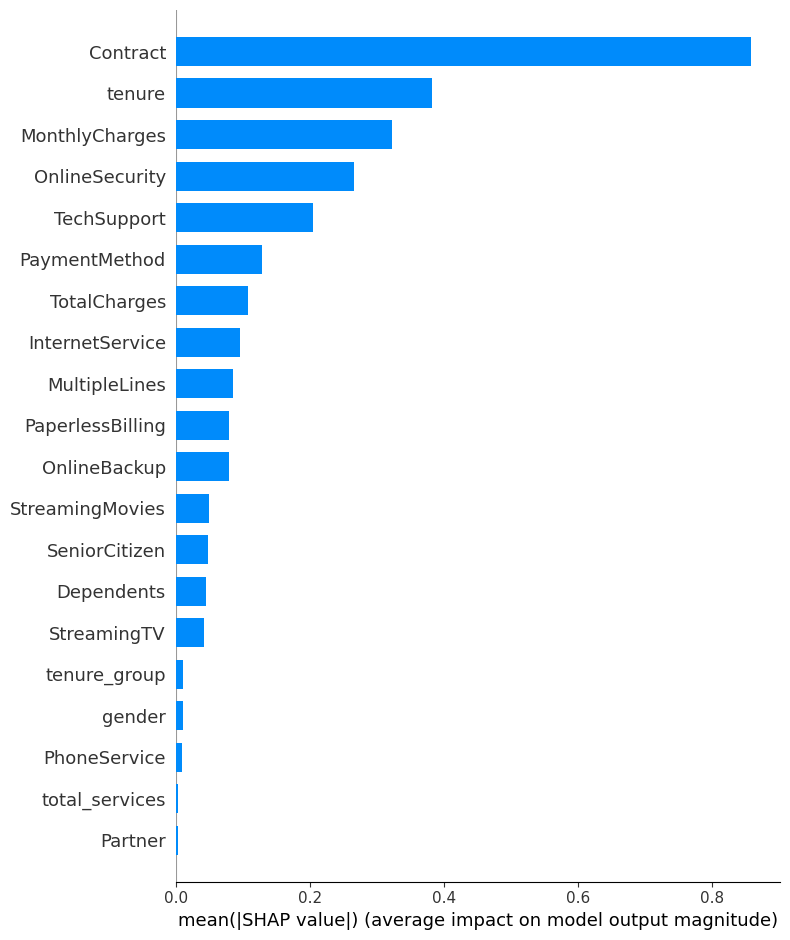

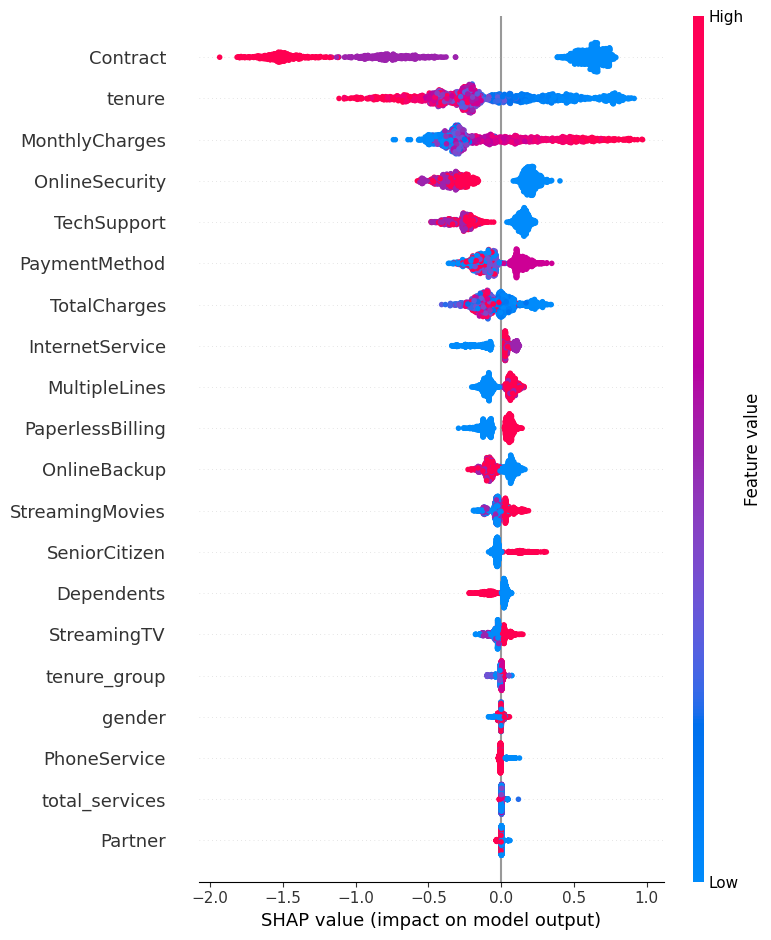

In [13]:
# Cell 4 — Step 5 & 6: SHAP + Business Recommendations

import shap
import matplotlib.pyplot as plt

# SHAP explainability
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

# Detailed SHAP plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=True)